In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import igraph as ig
import leidenalg
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph

DATA_PATH  = library_path.parent / 'data'
PLOTS_PATH = library_path.parent / 'plots'
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

In [3]:
df = pd.read_csv(DATA_PATH / 'wrangled_data.csv', low_memory=False)
print(f'Full dataset: {len(df):,} rows x {df.shape[1]} columns')
print(df['dataset'].value_counts().to_string())

Full dataset: 38,340 rows x 64 columns
dataset
HSE 2019        8026
HSE 2018        7990
HSE 2017        7840
HSE 2022        7590
DAPHNIE 2024    5237
DAPHNIE 2023    1657


In [4]:
EXTRA_FEATURES = [
    "paVig", "paMod", "resp", "skin",
]
BASE_FEATURES = [
    "Sex", "age7cat", "eth2cat", "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed", "edu_cat_2", "smoke_ecig", "diabetes",
    "meds_num", "ill_dis"
]
ALL_FEATURES = BASE_FEATURES + EXTRA_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f"Features ({len(ALL_FEATURES)}):")
print(ALL_FEATURES)

Features (17):
['Sex', 'age7cat', 'eth2cat', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'edu_cat_2', 'smoke_ecig', 'diabetes', 'meds_num', 'ill_dis', 'paVig', 'paMod', 'resp', 'skin']


In [5]:
KEEP_DATASETS = ['DAPHNIE 2024', 'HSE 2017', 'HSE 2018']
df_r = df[df['dataset'].isin(KEEP_DATASETS)].copy().reset_index(drop=True)

print('Restricted dataset:')
print(df_r['dataset'].value_counts().to_string())
print(f'\nTotal: {len(df_r):,} rows')

# Gower distance = Manhattan distance / n_features on range-normalised data.
# Range normalisation maps every feature to [0, 1] on its own scale, so binary
# variables contribute 0 or 1, ordinal variables contribute a proportional rank
# difference, and no feature dominates due to scale differences.
imputer = SimpleImputer(strategy='median')
X_imp   = imputer.fit_transform(df_r[ALL_FEATURES])

# -----------------------------
# 3. MIN-MAX SCALING (Gower numeric part)
# -----------------------------
col_min = X_imp.min(axis=0)
col_range = X_imp.max(axis=0) - col_min
col_range = np.where(col_range > 0, col_range, 1.0)

X_scaled = (X_imp - col_min) / col_range
N, P = X_scaled.shape

Restricted dataset:
dataset
HSE 2018        7990
HSE 2017        7840
DAPHNIE 2024    5237

Total: 21,067 rows


## 1. kNN Similarity Graph

The similarity between two observations is $1 - d_{\text{Gower}}(i,j)$, which lies in
$[0, 1]$. Edges with negative similarity (distant pairs forced into the kNN) are clipped
to zero. The directed graph is symmetrised by averaging forward and backward weights.

`RBConfigurationVertexPartition` (RBC) is used for community detection. Unlike CPM,
RBC merges communities more aggressively at **lower** resolution: resolution = 0
collapses everything into one community; resolution = 1 is standard modularity.

In [17]:
from sklearn.neighbors import NearestNeighbors
from scipy.sparse import csr_matrix

K_GRAPH = 20  # kNN neighbourhood size

nbrs = NearestNeighbors(n_neighbors=K_GRAPH, metric='manhattan',
                        algorithm='auto', n_jobs=-1).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Similarity = 1 - Gower distance; clip negatives (very distant forced neighbours)
sims = np.clip(1 - distances / P, 0, 1)

rows = np.repeat(np.arange(N), K_GRAPH)
cols = indices.flatten()
W    = csr_matrix((sims.flatten(), (rows, cols)), shape=(N, N))
W    = 0.5 * (W + W.T)  # symmetrise

sources, targets = W.nonzero()
weights = np.array(W[sources, targets]).flatten()

g = ig.Graph(n=N, edges=list(zip(sources.tolist(), targets.tolist())),
             directed=False)
g.es['weight'] = weights.tolist()

print(f'Graph: {g.vcount():,} nodes, {g.ecount():,} edges')
print(f'Edge weight range: {min(weights):.3f} – {max(weights):.3f}')

Graph: 21,067 nodes, 558,168 edges
Edge weight range: 0.387 – 1.000


## 2. Resolution Sensitivity (RBConfigurationVertexPartition)

RBC with lower resolution merges communities more aggressively.
Sweep to find the resolution giving 5–15 communities.

In [18]:
RES_VALS = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0]
results  = []

for res in RES_VALS:
    part  = leidenalg.find_partition(g, leidenalg.RBConfigurationVertexPartition,
                                     weights='weight', seed=42,
                                     resolution_parameter=res)
    sizes = sorted([len(c) for c in part], reverse=True)
    results.append({
        'resolution': res,
        'n_communities': len(part),
        'largest': sizes[0],
        'smallest': sizes[-1],
        'Q': round(g.modularity(part.membership, weights='weight'), 4),
    })
    print(f'res={res:.3f} | communities={len(part):5d} | '
          f'largest={sizes[0]:6,} | smallest={sizes[-1]}')

display(pd.DataFrame(results).set_index('resolution'))
print()
print('Set RESOLUTION_FINAL to the value giving 5–15 communities.')

res=0.001 | communities=   10 | largest=15,151 | smallest=28
res=0.010 | communities=   16 | largest= 7,715 | smallest=28
res=0.050 | communities=   28 | largest= 3,061 | smallest=28
res=0.100 | communities=   39 | largest= 2,613 | smallest=21
res=0.250 | communities=   57 | largest= 1,754 | smallest=21
res=0.500 | communities=   73 | largest= 1,186 | smallest=21
res=1.000 | communities=   97 | largest=   809 | smallest=21


,n_communities,largest,smallest,Q
resolution,,,,
0.001,10,15151,28,0.414
0.010,16,7715,28,0.761
0.050,28,3061,28,0.896
0.100,39,2613,21,0.927
0.250,57,1754,21,0.950
0.500,73,1186,21,0.958
1.000,97,809,21,0.960



Set RESOLUTION_FINAL to the value giving 5–15 communities.


## 3. Final Partition

In [19]:
RESOLUTION_FINAL = 0.01  # adjust based on sensitivity table above

part_final = leidenalg.find_partition(g, leidenalg.RBConfigurationVertexPartition,
                                      weights='weight', seed=42,
                                      resolution_parameter=RESOLUTION_FINAL)

df_r['community'] = part_final.membership

# Rename by size (0 = largest)
order      = (df_r.groupby('community').size()
              .sort_values(ascending=False).index.tolist())
rename_map = {old: new for new, old in enumerate(order)}
df_r['community'] = df_r['community'].map(rename_map)

N_COMM = df_r['community'].nunique()
q      = g.modularity(part_final.membership, weights='weight')
print(f'Leiden (RBC, res={RESOLUTION_FINAL}): {N_COMM} communities, Q={q:.4f}')
print()
print('Community sizes:')
print(df_r['community'].value_counts().sort_index().to_string())

Leiden (RBC, res=0.01): 16 communities, Q=0.7611

Community sizes:
community
0     7715
1     5583
2     2469
3     1921
4     1546
5     1441
6       93
7       38
8       38
9       38
10      34
11      33
12      31
13      31
14      28
15      28


## 4. Community Profiles

### Sociodemographic features

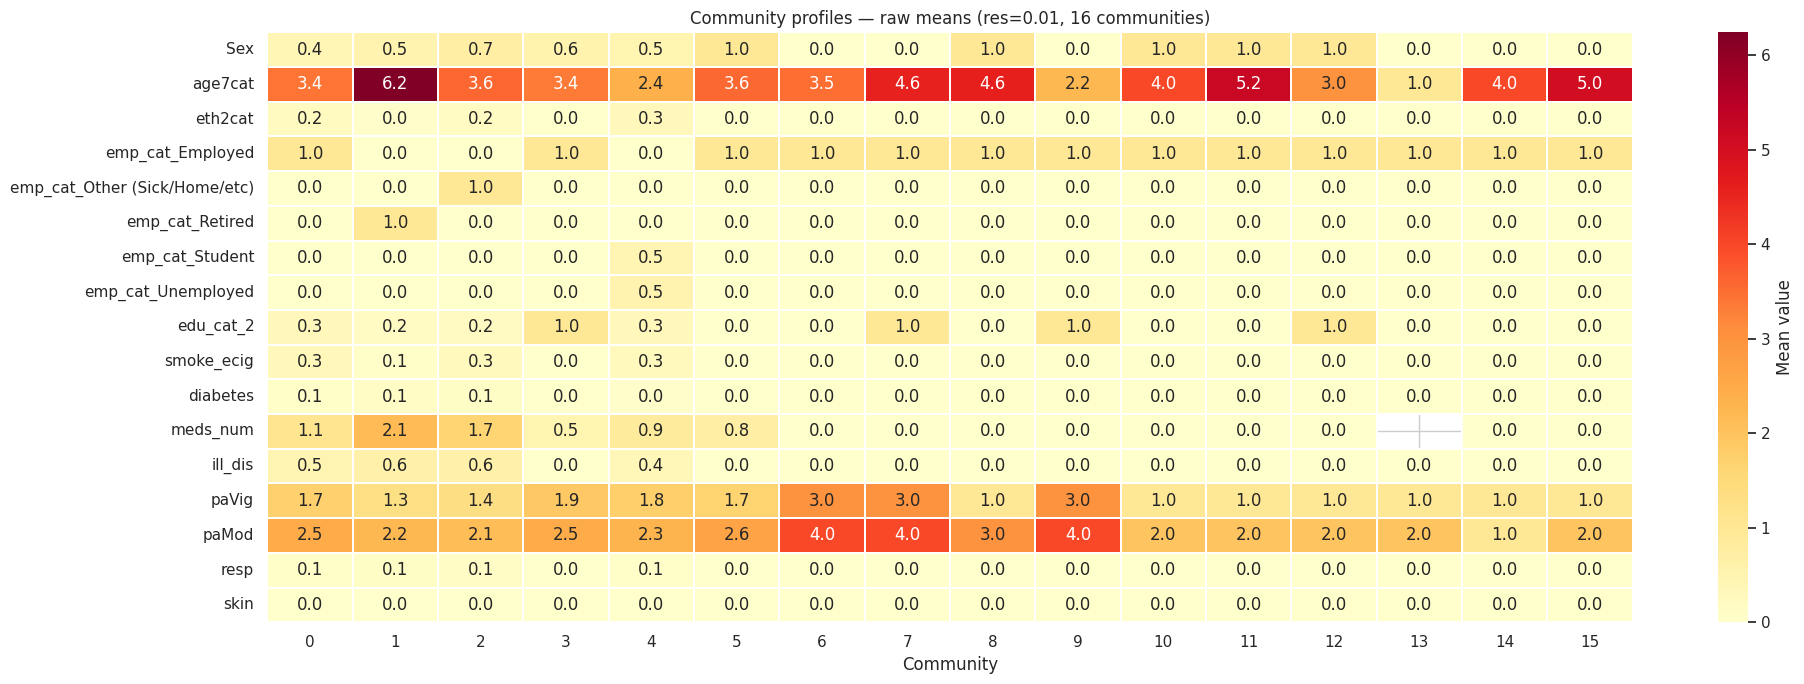

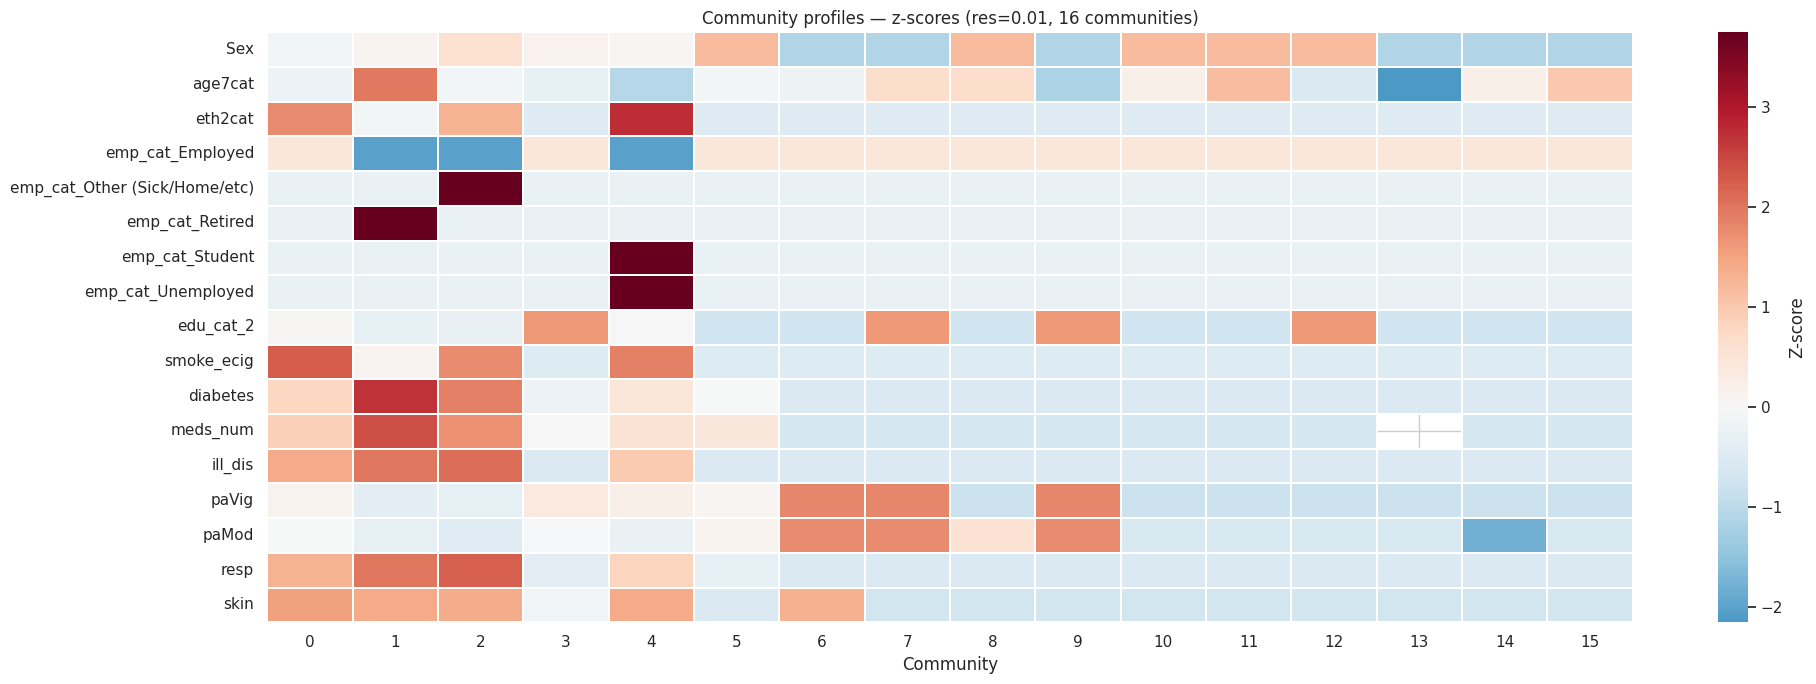

In [20]:
OUTCOMES = ['MO5L', 'SC5L', 'UA5L', 'PD5L', 'AD5L', 'EQ_index', 'LSS_rs', 'srh']
OUTCOMES = [o for o in OUTCOMES if o in df_r.columns]

profile_raw = df_r.groupby('community')[ALL_FEATURES].mean()
profile_z   = (profile_raw - profile_raw.mean()) / profile_raw.std().replace(0, 1)
W_fig = min(max(8, N_COMM * 1.4), 20)

fig, ax = plt.subplots(figsize=(W_fig, 7))
sns.heatmap(profile_raw.T, ax=ax, cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.3, cbar_kws={'label': 'Mean value'})
ax.set_title(f'Community profiles — raw means (res={RESOLUTION_FINAL}, {N_COMM} communities)')
ax.set_xlabel('Community')
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'community031_feature_profiles_raw.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(W_fig, 7))
sns.heatmap(profile_z.T, ax=ax, cmap='RdBu_r', center=0, annot=False,
            linewidths=0.3, cbar_kws={'label': 'Z-score'})
ax.set_title(f'Community profiles — z-scores (res={RESOLUTION_FINAL}, {N_COMM} communities)')
ax.set_xlabel('Community')
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'community031_feature_profiles_zscore.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close()

### Health outcome profiles

Health outcome means by community:


,MO5L,SC5L,UA5L,PD5L,AD5L,EQ_index,LSS_rs,srh
community,,,,,,,,
0,1.245,1.083,1.249,1.637,1.574,0.902,91.088,3.855
1,1.720,1.226,1.581,2.008,1.414,0.842,85.358,3.532
2,1.928,1.590,2.038,2.311,2.288,0.664,74.253,3.083
3,1.074,1.007,1.060,1.327,1.316,0.960,96.089,4.336
4,1.316,1.155,1.397,1.614,1.974,0.852,87.810,3.646
5,1.089,1.011,1.078,1.394,1.373,0.950,95.298,4.199
6,1.011,1.011,1.022,1.301,1.215,0.972,97.174,4.398
7,1.053,1.000,1.053,1.237,1.184,0.970,97.368,4.395
8,1.132,1.000,1.079,1.526,1.263,0.953,95.000,4.447


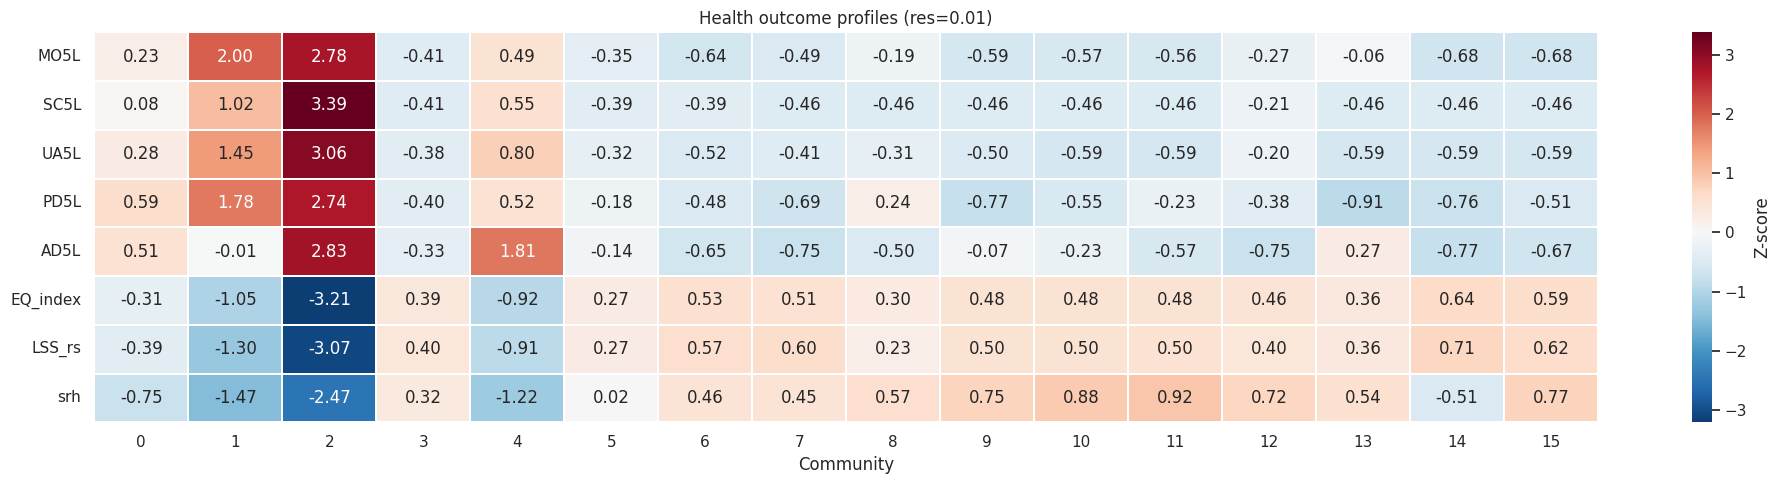

In [21]:
outcome_profile = df_r.groupby('community')[OUTCOMES].mean()
print('Health outcome means by community:')
display(outcome_profile.round(3))

outcome_z = (outcome_profile - outcome_profile.mean()) / outcome_profile.std().replace(0, 1)

fig, ax = plt.subplots(figsize=(W_fig, 5))
sns.heatmap(outcome_z.T, ax=ax, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.3, cbar_kws={'label': 'Z-score'})
ax.set_title(f'Health outcome profiles (res={RESOLUTION_FINAL})')
ax.set_xlabel('Community')
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'community031_outcome_profiles.png', dpi=100, bbox_inches='tight')
plt.show()

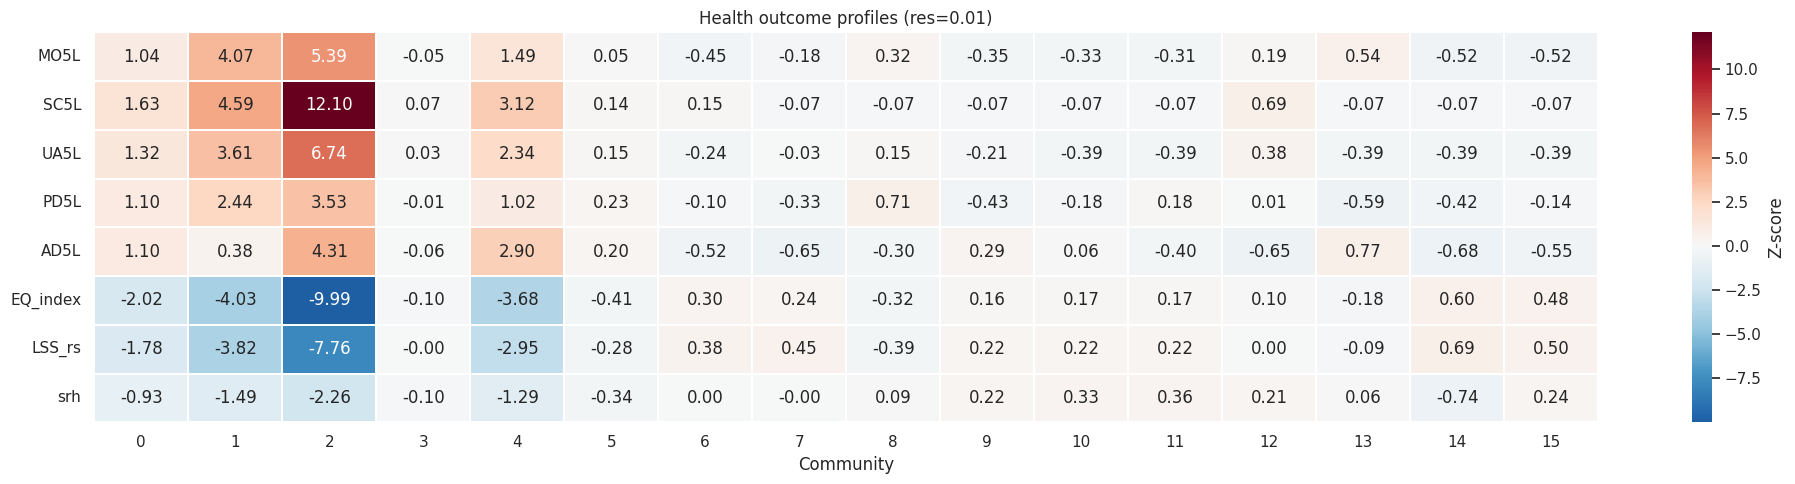

In [33]:
from numpy import percentile

med = outcome_profile.median()
iqr = outcome_profile.quantile(0.75) - outcome_profile.quantile(0.25)
iqr = iqr.replace(0, 1)
profile_robust = (outcome_profile - med) / iqr
np.round(profile_robust, 3)

fig, ax = plt.subplots(figsize=(W_fig, 5))
sns.heatmap(profile_robust.T, ax=ax, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.3, cbar_kws={'label': 'Z-score'})
ax.set_title(f'Health outcome profiles (res={RESOLUTION_FINAL})')
ax.set_xlabel('Community')
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'community031_outcome_profiles_robust.png', dpi=600, bbox_inches='tight')
plt.show()

In [28]:
print(outcome_z)

            MO5L   SC5L   UA5L   PD5L   AD5L  EQ_index  LSS_rs    srh
community                                                            
0          0.229  0.084  0.284  0.590  0.515    -0.313  -0.393 -0.749
1          2.002  1.018  1.452  1.775 -0.006    -1.046  -1.303 -1.470
2          2.778  3.388  3.057  2.742  2.832    -3.212  -3.066 -2.470
3         -0.408 -0.409 -0.380 -0.400 -0.326     0.385   0.400  0.322
4          0.493  0.552  0.802  0.518  1.814    -0.919  -0.914 -1.215
5         -0.351 -0.387 -0.317 -0.184 -0.138     0.272   0.275  0.017
6         -0.644 -0.386 -0.516 -0.482 -0.652     0.530   0.572  0.460
7         -0.488 -0.456 -0.407 -0.687 -0.752     0.508   0.603  0.453
8         -0.193 -0.456 -0.314  0.237 -0.496     0.304   0.227  0.571
9         -0.586 -0.456 -0.499 -0.771 -0.069     0.479   0.499  0.747
10        -0.571 -0.456 -0.592 -0.545 -0.234     0.483   0.500  0.885
11        -0.560 -0.456 -0.592 -0.232 -0.567     0.482   0.501  0.924
12        -0.270 -0.

## 5. Community Composition by Dataset

% from each dataset per community (rows sum to 100%):


dataset,DAPHNIE 2024,HSE 2017,HSE 2018
community,,,
0,24.900,37.000,38.100
1,19.600,40.600,39.900
2,26.400,36.000,37.500
3,23.200,38.300,38.500
4,45.700,25.100,29.200
5,23.700,38.700,37.600
6,33.300,36.600,30.100
7,44.700,21.100,34.200
8,2.600,39.500,57.900


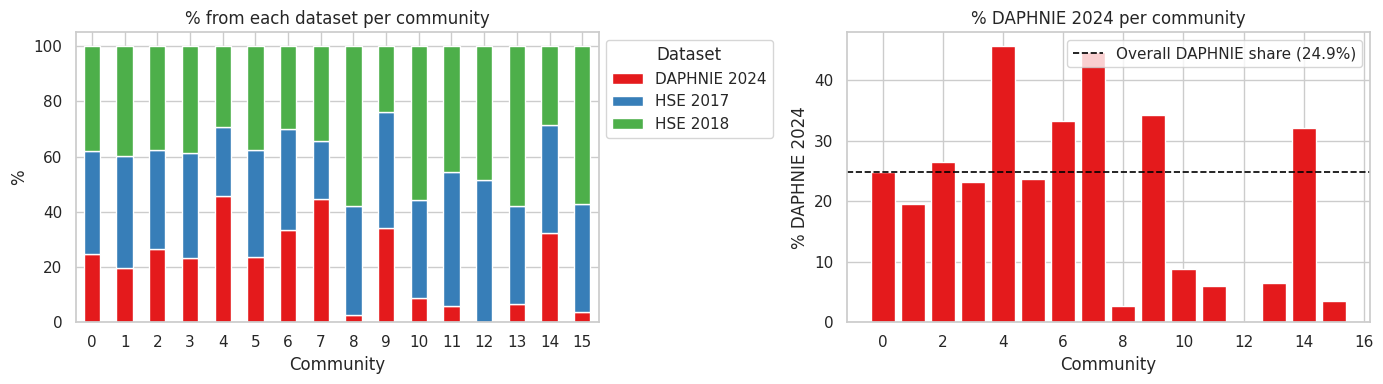

In [22]:
DATASET_COLOURS = {'DAPHNIE 2024': '#e41a1c', 'HSE 2017': '#377eb8', 'HSE 2018': '#4daf4a'}
overall_daphnie = (df_r['dataset'] == 'DAPHNIE 2024').mean() * 100

comp_n       = df_r.groupby(['community', 'dataset']).size().unstack(fill_value=0)
comp_pct_row = comp_n.div(comp_n.sum(axis=1), axis=0).mul(100)

print('% from each dataset per community (rows sum to 100%):')
display(comp_pct_row.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

comp_pct_row[[c for c in DATASET_COLOURS if c in comp_pct_row.columns]].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[DATASET_COLOURS[c] for c in DATASET_COLOURS if c in comp_pct_row.columns],
    edgecolor='white')
axes[0].set_title('% from each dataset per community')
axes[0].set_xlabel('Community'); axes[0].set_ylabel('%')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Dataset', bbox_to_anchor=(1, 1))

daphnie_pct = comp_pct_row.get('DAPHNIE 2024', pd.Series(dtype=float))
axes[1].bar(daphnie_pct.index, daphnie_pct.values, color='#e41a1c', edgecolor='white')
axes[1].axhline(overall_daphnie, color='black', linestyle='--', linewidth=1.2,
                label=f'Overall DAPHNIE share ({overall_daphnie:.1f}%)')
axes[1].set_title('% DAPHNIE 2024 per community')
axes[1].set_xlabel('Community'); axes[1].set_ylabel('% DAPHNIE 2024')
axes[1].legend(); axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(PLOTS_PATH / 'community031_composition.png', dpi=100, bbox_inches='tight')
plt.show()

In [23]:
print(comp_pct_row.round(1))

dataset    DAPHNIE 2024  HSE 2017  HSE 2018
community                                  
0                24.900    37.000    38.100
1                19.600    40.600    39.900
2                26.400    36.000    37.500
3                23.200    38.300    38.500
4                45.700    25.100    29.200
5                23.700    38.700    37.600
6                33.300    36.600    30.100
7                44.700    21.100    34.200
8                 2.600    39.500    57.900
9                34.200    42.100    23.700
10                8.800    35.300    55.900
11                6.100    48.500    45.500
12                0.000    51.600    48.400
13                6.500    35.500    58.100
14               32.100    39.300    28.600
15                3.600    39.300    57.100


## 6. Agreement with K-means (Notebook 01)

K-means with $k=6$ is re-run on the same Gower-normalised features for consistency.
ARI = 1 is perfect agreement; ARI = 0 is chance-level.

ARI — Leiden (RBC) vs k-means (k=6): 0.4245


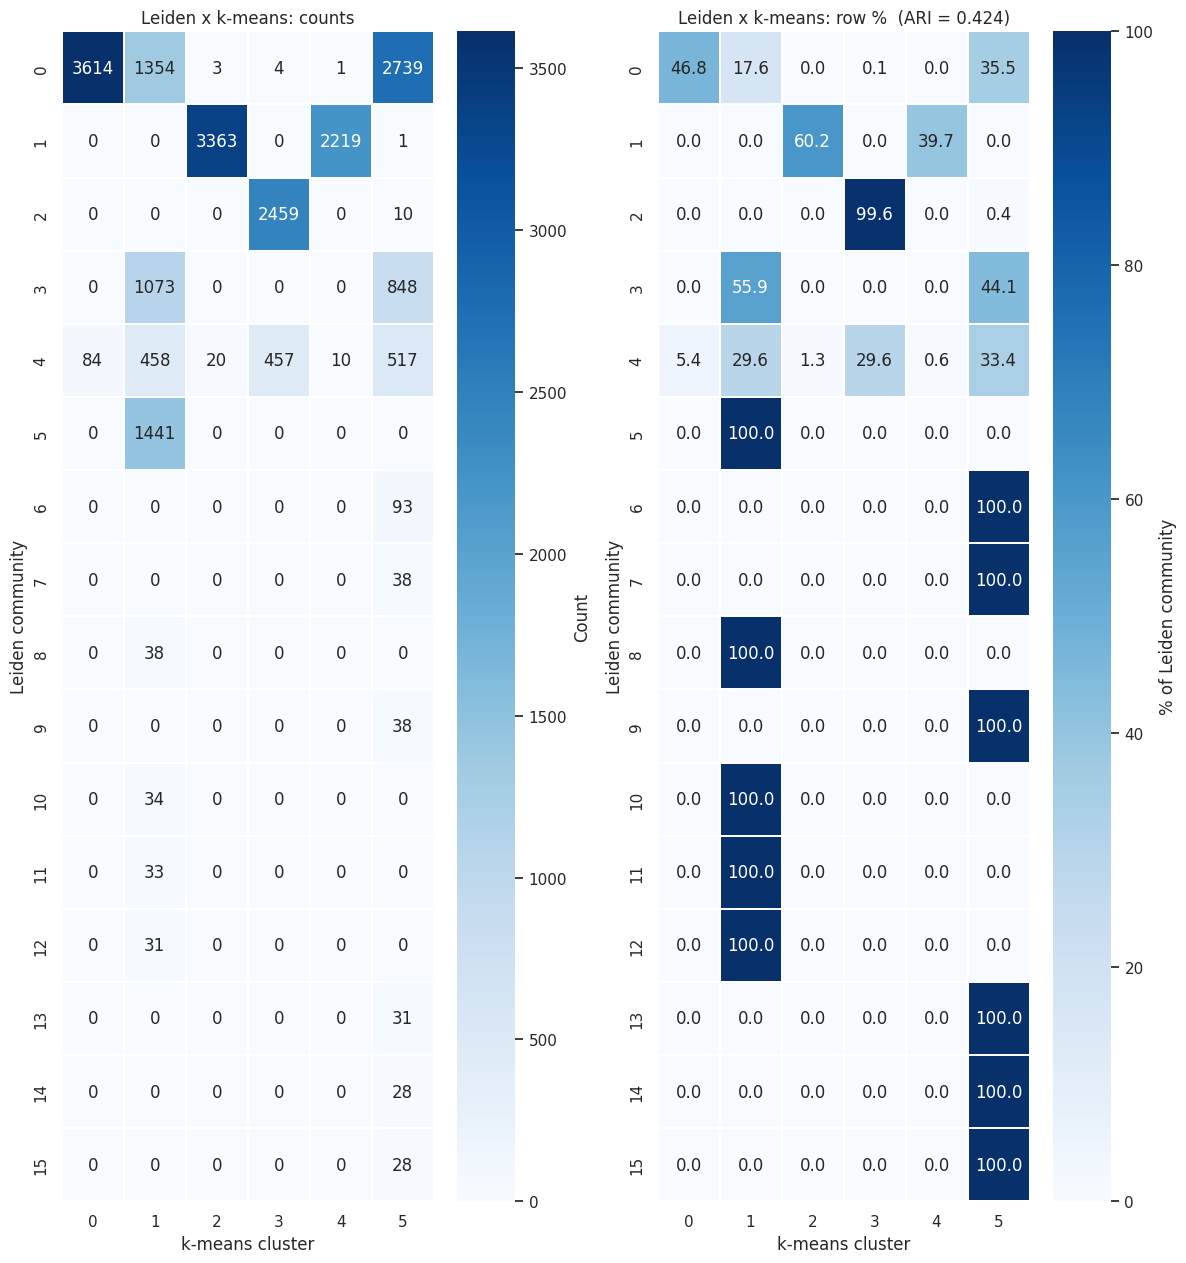

In [25]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

K_KMEANS = 6
km = KMeans(n_clusters=K_KMEANS, n_init=20, max_iter=300, random_state=42)
df_r['cluster_km'] = km.fit_predict(X_scaled)

ari = adjusted_rand_score(df_r['community'], df_r['cluster_km'])
print(f'ARI — Leiden (RBC) vs k-means (k={K_KMEANS}): {ari:.4f}')

cross     = pd.crosstab(df_r['community'], df_r['cluster_km'],
                        rownames=['Leiden community'], colnames=['k-means cluster'])
cross_pct = cross.div(cross.sum(axis=1), axis=0).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(12, max(4, N_COMM * 0.8)))
sns.heatmap(cross, ax=axes[0], cmap='Blues', annot=True, fmt='d',
            linewidths=0.3, cbar_kws={'label': 'Count'})
axes[0].set_title('Leiden x k-means: counts')

sns.heatmap(cross_pct, ax=axes[1], cmap='Blues', annot=True, fmt='.1f',
            linewidths=0.3, cbar_kws={'label': '% of Leiden community'})
axes[1].set_title(f'Leiden x k-means: row %  (ARI = {ari:.3f})')

plt.tight_layout()
plt.savefig(PLOTS_PATH / 'community031_vs_kmeans.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. UMAP Overlay

Fitting UMAP (this may take 1-2 minutes)...


/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/home/luisggon/.cache/pypoetry/virtualenvs/euroqol-1goflkTH-py3.12/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


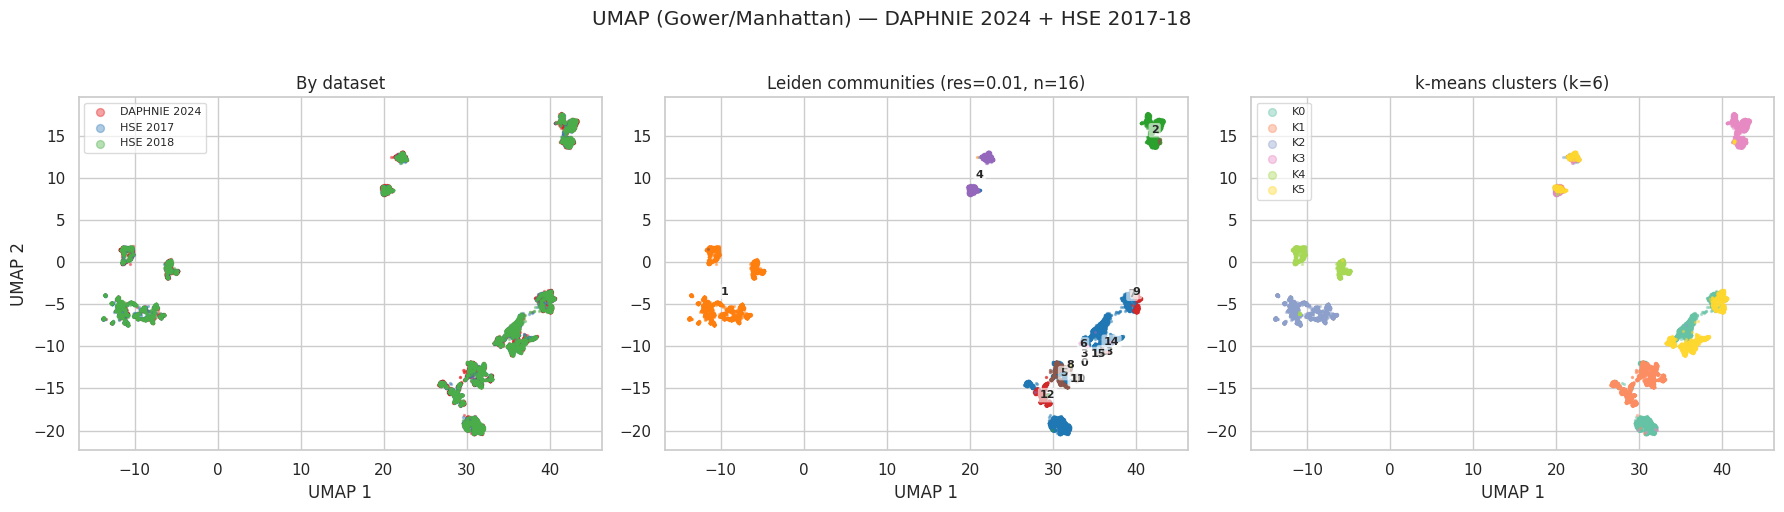

In [26]:
import umap

print('Fitting UMAP (this may take 1-2 minutes)...')
reducer   = umap.UMAP(n_neighbors=50, min_dist=0.1, n_components=2,
                      metric='hamming', random_state=42)
embedding = reducer.fit_transform(X_scaled)
df_r['umap1'] = embedding[:, 0]
df_r['umap2'] = embedding[:, 1]
print('Done.')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1 — by dataset (3 items: legend inside is fine)
for ds, colour in DATASET_COLOURS.items():
    mask = df_r['dataset'] == ds
    axes[0].scatter(df_r.loc[mask, 'umap1'], df_r.loc[mask, 'umap2'],
                    c=colour, s=2, alpha=0.4, label=ds, rasterized=True)
axes[0].set_title('By dataset')
axes[0].legend(markerscale=4, framealpha=0.7, fontsize=8)
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')

# Panel 2 — Leiden communities: annotate centroids instead of legend
comm_palette = sns.color_palette('tab10', max(N_COMM, 10))
for c_id in sorted(df_r['community'].unique()):
    mask = df_r['community'] == c_id
    axes[1].scatter(df_r.loc[mask, 'umap1'], df_r.loc[mask, 'umap2'],
                    c=[comm_palette[c_id % 10]], s=2, alpha=0.4, rasterized=True)
    cx = df_r.loc[mask, 'umap1'].mean()
    cy = df_r.loc[mask, 'umap2'].mean()
    axes[1].text(cx, cy, str(c_id), fontsize=8, fontweight='bold', ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6, lw=0))
axes[1].set_title(f'Leiden communities (res={RESOLUTION_FINAL}, n={N_COMM})')
axes[1].set_xlabel('UMAP 1')

# Panel 3 — k-means (6 items: legend inside is fine)
km_palette = sns.color_palette('Set2', K_KMEANS)
for k_id in sorted(df_r['cluster_km'].unique()):
    mask = df_r['cluster_km'] == k_id
    axes[2].scatter(df_r.loc[mask, 'umap1'], df_r.loc[mask, 'umap2'],
                    c=[km_palette[k_id]], s=2, alpha=0.4,
                    label=f'K{k_id}', rasterized=True)
axes[2].set_title(f'k-means clusters (k={K_KMEANS})')
axes[2].legend(markerscale=4, framealpha=0.7, fontsize=8)
axes[2].set_xlabel('UMAP 1')

plt.suptitle('UMAP (Gower/Manhattan) — DAPHNIE 2024 + HSE 2017-18', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_PATH / 'community031_umap.png', dpi=100, bbox_inches='tight')
plt.show()